In [2]:
# 在当前文件中测试空间分析与坐标变换的功能
# 尝试使用 gdal实现对栅格数据的裁剪操作，仿照采用 rasterio 的方式进行裁剪
from osgeo import gdal
import geopandas as gpd
import os

# 1. 设置输入输出路径
data_path_file = r'D:\\pyLearn\\test_project\\data\\tif\\v_mean_15_25.tif'  # 替换为你要裁剪的数据的文件夹路径
shp_path = r'D:\\pyLearn\\test_project\\data\\shp\\result_no_Sea.shp'  # 替换为shp文件路径
clipped_data_file = r'D:\\pyLearn\\test_project\\data\\tif\\clipped.tif'  # 替换为裁剪后数据的输出文件路径

options=gdal.WarpOptions(
    cutlineDSName=shp_path, 
    cropToCutline=True, 
    dstSRS='EPSG:4326',  # 输出坐标系为WGS84
    dstNodata=0,
    resampleAlg=gdal.GRA_Bilinear,  # 双线性插值
    format='GTiff'
)

# 裁剪
gdal.Warp(clipped_data_file, data_path_file, options=options)

d:\pytorch\envs\geo_ai\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x0000014CD4B56B70> >

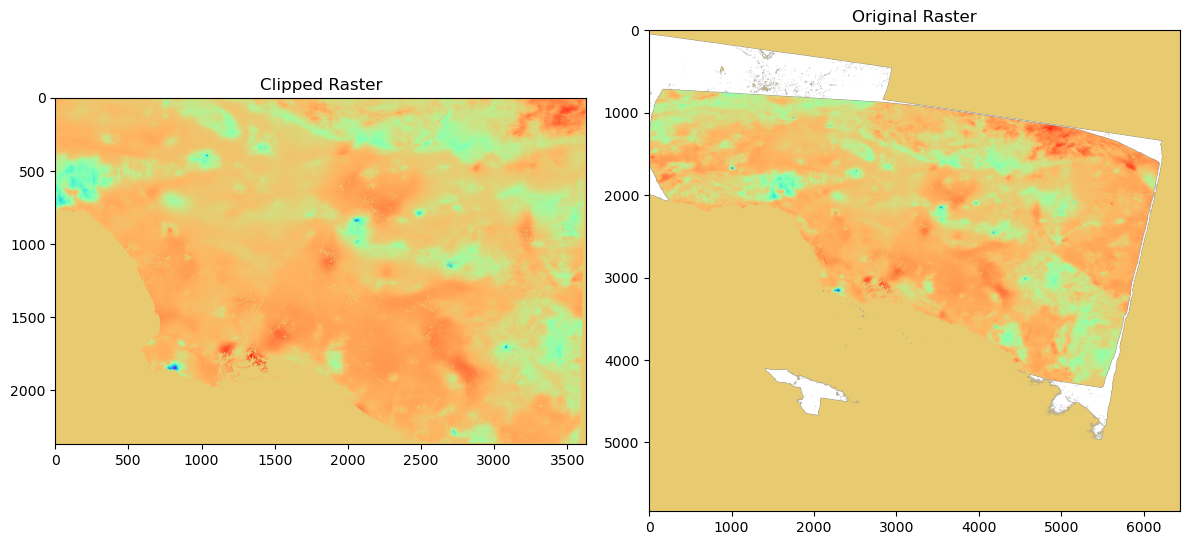

In [3]:
from toolbox.raster import metadata
from matplotlib import pyplot as plt
# 2. 读取裁剪后的数据进行验证
with gdal.Open(clipped_data_file) as ds, gdal.Open(data_path_file) as dataset:
    metadata.get_dataset_info(ds)
    band =ds.GetRasterBand(1)
    band2=dataset.GetRasterBand(1)
    array = band.ReadAsArray()
    array2=band2.ReadAsArray()
    # 3. 可视化裁剪结果
    # 创建两个子图
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    # 在第一个子图中显示裁剪后的数据
    axes[0].set_title('Clipped Raster')
    axes[0].imshow(array, cmap='rainbow')
    # 在第二个子图中显示原始数据
    axes[1].set_title('Original Raster')
    axes[1].imshow(array2, cmap='rainbow')
    plt.tight_layout()
    plt.show()

In [5]:
# 人为创建一个多波段数据
from toolbox.raster import bands
from osgeo import gdal
# 创建一个新的多波段数据
input_files=[
    r'D:\\pyLearn\\test_project\\data\\tif\\clipped.tif',
    r'D:\\pyLearn\\test_project\\data\\tif\\v_mean_15_25.tif',
    r'D:\\pyLearn\\test_project\\data\\tif\\v_mean_15_25.tif']
output_file=r'D:\\pyLearn\\test_project\\data\\tif\\multiband.tif'
bands.stack_bands(input_files, output_file)

正在转换 VRT 到 GeoTIFF: D:\\pyLearn\\test_project\\data\\tif\\multiband.tif ...
成功: 已合并 3 个波段。


True

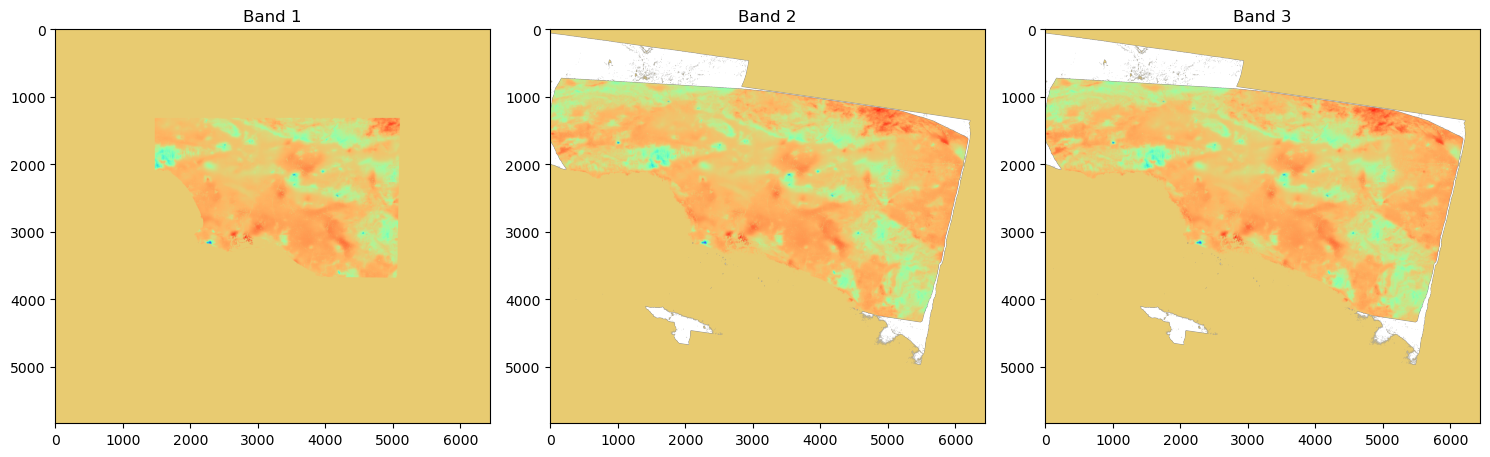

In [6]:
with gdal.Open(output_file) as ds:
    band1= ds.GetRasterBand(1)
    band2= ds.GetRasterBand(2)  
    band3= ds.GetRasterBand(3)
    array1=band1.ReadAsArray()
    array2=band2.ReadAsArray()
    array3=band3.ReadAsArray()
from matplotlib import pyplot as plt
# 创建三个子图  
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# 在第一个子图中显示第一波段数据
axes[0].set_title('Band 1')
axes[0].imshow(array1, cmap='rainbow')
# 在第二个子图中显示第二波段数据    
axes[1].set_title('Band 2')
axes[1].imshow(array2, cmap='rainbow')
# 在第三个子图中显示第三波段数据    
axes[2].set_title('Band 3')
axes[2].imshow(array3, cmap='rainbow')
plt.tight_layout()

In [20]:
# 使用rasterio读取多波段数据进行验证
import rasterio
with rasterio.open(output_file) as dataset:
     print(dataset.count)  # 波段数量
     print(dataset.width, dataset.height)  # 栅格数据的宽度和高度
     for i,dtype,band in zip (dataset.indexes, dataset.dtypes,dataset.read()):
         print(i, dtype,band.shape)  # 每个波段的数据类型,仿射变换参数
         print(band[200,100]) # 访问特定位置的像素值
         print(dataset.xy(dataset.width//2, dataset.height//2)) # 访问图像中心的地理坐标

3
6440 5835
1 float32 (5835, 6440)
0.0
(np.float64(-118.18972221574), np.float64(33.7261111484))
2 float32 (5835, 6440)
nan
(np.float64(-118.18972221574), np.float64(33.7261111484))
3 float32 (5835, 6440)
nan
(np.float64(-118.18972221574), np.float64(33.7261111484))
